# L11d Lab: Value Iteration in a Stochastic Grid World

> **Learning objectives**
>
> - Construct a stochastic state-action transition tensor.
> - Iterate Bellman optimality backups to a stated tolerance.
> - Extract a greedy policy and preserve terminal-state semantics.
> - Check transition sums and the final Bellman residual.


## Setup

Run the local setup cell first. It activates the pinned course environment, loads every package used by this meeting, and includes the `Week11Core` module from [`../src/Week11Core.jl`](../src/Week11Core.jl), which provides the functions called below.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes the meeting's local source. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:


In [1]:
include(joinpath(@__DIR__, "Include.jl"))


The setup cell completed, so the environment and this lab's local source are loaded. The cell below constructs the stochastic grid world in `world::NamedTuple`, whose fields include the transition array `P::Array{Float64, 3}`, `rewards::Vector{Float64}`, `terminal::BitVector`, and `gamma::Float64`. Value iteration then returns `solution::NamedTuple`, carrying `values::Vector{Float64}`, `policy::Vector{Int64}`, `residuals::Vector{Float64}`, `iterations::Int64`, and `converged::Bool`, rendered per state in `policy_table::DataFrame`.


In [2]:
world = classic_gridworld(slip = 0.1, gamma = 0.95, step_reward = -0.04)
solution = value_iteration(world.P, world.rewards, world.gamma; terminal = world.terminal)

policy_labels = [world.terminal[state] ? "terminal" : world.action_names[solution.policy[state]] for state in eachindex(world.coordinates)]
policy_table = DataFrame(state = eachindex(world.coordinates), coordinate = string.(world.coordinates),
    value = solution.values, action = policy_labels)
pretty_table(policy_table)
(iterations = solution.iterations, final_residual = last(solution.residuals))


┌───────┬────────────┬──────────┬──────────┐
│ state │ coordinate │    value │   action │
│ Int64 │     String │  Float64 │   String │
├───────┼────────────┼──────────┼──────────┤
│     1 │     (1, 1) │ 0.646793 │        → │
│     2 │     (1, 2) │ 0.753141 │        → │
│     3 │     (1, 3) │ 0.855321 │        → │
│     4 │     (1, 4) │      1.0 │ terminal │
│     5 │     (2, 1) │ 0.557485 │        ↑ │
│     6 │     (2, 3) │ 0.569109 │        ↑ │
│     7 │     (2, 4) │     -1.0 │ terminal │
│     8 │     (3, 1) │ 0.464535 │        ↑ │
│     9 │     (3, 2) │ 0.386477 │        ← │
│    10 │     (3, 3) │ 0.451052 │        ↑ │
│    11 │     (3, 4) │ 0.229612 │        ← │
└───────┴────────────┴──────────┴──────────┘


(iterations = 37, final_residual = 6.455519452330805e-11)

In [3]:
@test solution.converged
@test solution.values[world.index[(1, 4)]] == 1.0
@test solution.values[world.index[(2, 4)]] == -1.0
@test all(abs.(sum(world.P; dims = 3) .- 1.0) .< 1e-12)
@test last(solution.residuals) <= 1e-10
:value_iteration_verified


:value_iteration_verified

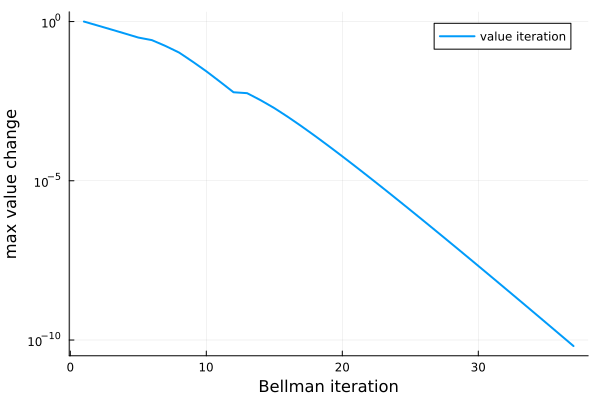

In [4]:
plot(solution.residuals; yscale = :log10, lw = 2, xlabel = "Bellman iteration", ylabel = "max value change", label = "value iteration")


## Summary

The optimal arrows account for slip risk and delayed reward, not just geometric distance. The value function and policy are conditional on the transition probabilities, reward scale, discount factor, wall, and terminal definitions.
